In [1]:

from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt

import os 

from file_management import get_version_folder, save_config, load_config
from refined_progan import Generator, Discriminator
from CityScapes import CityScapesMultiScaleDataset


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
list_to_device = lambda xs,device :[x.to(device) for x in xs]
detach_list = lambda xs: [x.detach() for x in xs]

In [2]:
load_run = None

In [3]:
if load_run:
    config_path = os.path.join(load_run,'config.yaml')
    load_step = 5
    config = load_config(config_path)
    config['root_path'] = load_run

else:
    root = 'cache/progan'
    index_folder = get_version_folder(root)
    config = load_config('config.yaml')
    config['root_path'] =index_folder

    config_target_path = os.path.join(index_folder,'config.yaml')
    save_config(config, config_target_path)




Config saved to cache/progan/15/config.yaml


In [4]:
index_folder

'cache/progan/15'

In [5]:
z_dim =config['z_dim']
channels = config['channels']
batch_size = config['batch_size']

gen_lr = config['gen_lr']
disc_lr = config['dis_lr']

gen_path = os.path.join(index_folder,'gen')
disc_path = os.path.join(index_folder,'dis')

samples_path = os.path.join(index_folder,'samples')
os.makedirs(samples_path)


In [6]:
dataset = CityScapesMultiScaleDataset()
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


Dataset initialized with 19998 samples. Labels enabled: False


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14117646..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.17661339..1.9220004].


Text(0.5, 1.0, 'Fake')

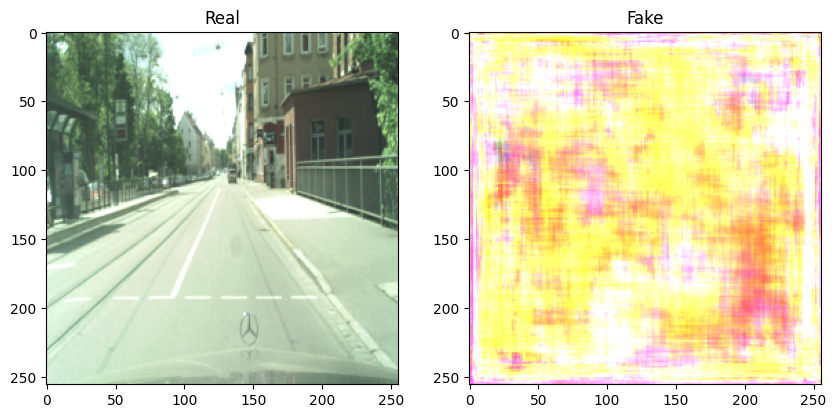

In [7]:

gen = Generator(z_dim,channels).to(device)
disc = Discriminator(channels).to(device)

gen_optimizer = Adam(gen.parameters(), lr=gen_lr, betas=(0.0, 0.9))
disc_optimizer = Adam(disc.parameters(), lr=disc_lr, betas=(0.0, 0.9))
noise =  torch.randn(1,z_dim,1,1).to(device)
fake = gen(noise)
disc_fake = disc(fake)

real,_ = next(iter(loader))
real = list_to_device(real,device)
disc_real = disc(real)

fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(real[-1][0].cpu().detach().permute(1,2,0).numpy()+1)
ax[0].set_title('Real')
ax[1].imshow(fake[-1][0].cpu().detach().permute(1,2,0).numpy()+1)
ax[1].set_title('Fake')

In [8]:
import torch

def compute_gradient_penalty(critic, real_images, fake_images):
    """
    Calculates the WGAN Gradient Penalty for a Multi-Scale GAN.
    
    Args:
        critic (nn.Module): The discriminator network.
        real_images (list of Tensors): List of real images at different scales.
        fake_images (list of Tensors): List of fake images at different scales.
        
    Returns:
        torch.Tensor: The computed gradient penalty scalar.
    """
    batch_size = real_images[0].shape[0]
    device = real_images[0].device
    
    # 1. Create a single random interpolation weight for the batch
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    
    # 2. Interpolate between real and fake at every scale
    interpolated_images = []
    for real_img, fake_img in zip(real_images, fake_images):
        mixed = (alpha * real_img + (1 - alpha) * fake_img).requires_grad_(True)
        interpolated_images.append(mixed)
        
    # 3. Pass the mixed images through the critic
    mixed_scores = critic(interpolated_images)
    
    # 4. Calculate the gradients of the scores w.r.t the mixed images
    gradients = torch.autograd.grad(
        outputs=mixed_scores,
        inputs=interpolated_images,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )
    
    # 5. Compute the penalty across all scales
    gradient_penalty = 0.0
    for grad in gradients:
        # Flatten the spatial dimensions: [batch_size, channels, H, W] -> [batch_size, -1]
        grad_flat = grad.view(batch_size, -1)
        # Calculate L2 norm (add epsilon to prevent NaN during backprop if norm is exactly 0)
        grad_norm = grad_flat.norm(2, dim=1) + 1e-8
        # Penalize deviation from 1.0
        gradient_penalty += torch.mean((grad_norm - 1.0) ** 2)
        
    return gradient_penalty / len(gradients)



In [ ]:
epochs =1000

for epoch in range(12,epochs):
    loop = tqdm(loader)
    loop.set_description("Epoch {}/{}".format(epoch+1,epochs))

    for i, (real,_) in enumerate(loop):
        real = list_to_device(real,device)
        current_batch_size = real[0].shape[0]
        

        disc_optimizer.zero_grad()
        with torch.no_grad():
            noise = torch.randn(current_batch_size, z_dim,1,1).to(device)
            fake = gen(noise)
        fake_detached = detach_list(fake)

        disc_fake = disc(fake_detached)

        disc_real = disc(real)
        # Calculate individual loss components
        loss_adv =  (torch.mean(disc_fake) - torch.mean(disc_real))
        loss_drift = 0.001 * (torch.mean(disc_real ** 2))#s + torch.mean(disc_fake ** 2))
        loss_gp = compute_gradient_penalty(disc, real, fake_detached)
        # Combine and step
        loss_disc = loss_adv + loss_drift + (10.0 * loss_gp)
        loss_disc.backward()
        disc_optimizer.step()

        gen_optimizer.zero_grad()
        noise = torch.randn(current_batch_size, z_dim,1,1).to(device)
        fake = gen(noise)
        disc_fake = disc(fake)
        loss_gen = - torch.mean(disc_fake)

        loss_gen.backward()
        gen_optimizer.step()
        loop.set_postfix(loss_disc=loss_disc.item(),loss_gen=loss_gen.item())

    torch.save(gen.state_dict(), gen_path)
    torch.save(disc.state_dict(),disc_path)
    fig,ax = plt.subplots(1,2,figsize=(10,5))
    with torch.no_grad():
        noise = torch.randn(current_batch_size, z_dim,1,1).to(device)
        fake = gen(noise) 
    ax[0].imshow((fake[-1][0].permute(1,2,0).cpu().numpy()+1)/2)
    ax[1].imshow((fake[-1][1].permute(1,2,0).cpu().numpy()+1)/2)
    plt.savefig(os.path.join(samples_path,'{}.png'.format(epoch)))
    plt.close()




Epoch 13/1000:   8%|▊         | 199/2500 [01:59<22:52,  1.68it/s, loss_disc=-16.8, loss_gen=-34.1]  

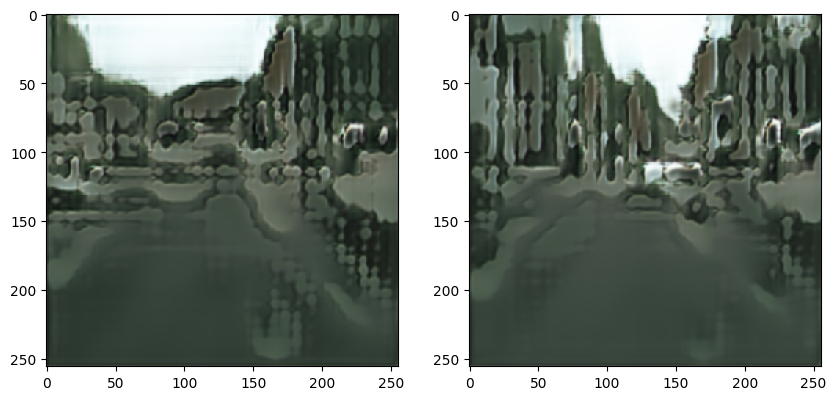

In [ ]:
import matplotlib.pyplot as plt
with torch.no_grad():
    noise =torch.randn(8,z_dim,1,1).to(device)
    fake = gen(noise)
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow((fake[-1][0].permute(1,2,0).cpu().numpy()+1)/2)
ax[1].imshow((fake[-1][1].permute(1,2,0).cpu().numpy()+1)/2)